# Closed-loop SSL+AL — RBF with Dual-Teacher

This notebook implements the RBF closed-loop SSL+AL pipeline with the Dual-Teacher scoring (Option B: product of normalized CE to KNN and RBF-teacher).
Place `electricity.csv` in `data/` before running.


In [11]:
import os, math, time, joblib, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
plt.rcParams['figure.figsize'] = (8,4)

TARGET_COL = 'target'
CONFIG = {
    'csv_path': 'datasets/electricity.csv',
    'target_col': TARGET_COL,
    'drop_cols': [],
    'test_size': 0.2,
    'initial_labeled': 200,
    'chunk_size': 500,
    'budget_per_chunk': 20,
    'knn_k': 5,
    'mlp_hidden': (64,),
    'mlp_max_iter_partial': 1,
    'random_seed': 42,
    'save_plots': True,
    'rbf_n_centers': 30,
    'rbf_lr': 0.05,
    'rbf_sigma_scale': 1.0,
    'rbf_init_epochs': 10,
    'rbf_online_epochs': 1,
    'dual_teacher': True,
}
print('CONFIG ready')


CONFIG ready


In [12]:
def prepare_data(df, cfg):
    df = df.copy()
    df.dropna(inplace=True)
    for c in cfg['drop_cols']:
        if c in df.columns:
            df.drop(columns=c, inplace=True)
    if cfg['target_col'] not in df.columns:
        possible = [c for c in df.columns if c.lower() in ('class','label','target')]
        if possible:
            cfg['target_col'] = possible[0]
        else:
            raise ValueError('Please set the correct target column in CONFIG["target_col"]')
    y = df[cfg['target_col']].values
    X = df.drop(columns=[cfg['target_col']]).select_dtypes(include=[np.number]).copy()
    if X.shape[1] == 0:
        raise ValueError('No numeric feature columns detected.')
    uniq = np.unique(y)
    if len(uniq) > 2:
        thr = np.median(y)
        y = (y > thr).astype(int)
    else:
        if len(uniq) == 2:
            mapping = {uniq[0]: 0, uniq[1]: 1}
            y = np.vectorize(lambda v: mapping[v])(y)
    return X.values, y

def chunk_generator(X, y, chunk_size):
    n = X.shape[0]
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        yield start, end, X[start:end], y[start:end]

def one_hot_from_label(labels, n_classes):
    oh = np.zeros((len(labels), n_classes), dtype=float)
    for i, lab in enumerate(labels):
        oh[i, lab] = 1.0
    return oh

def cross_entropy(p_model, p_target, eps=1e-12):
    p_model = np.clip(p_model, eps, 1 - eps)
    return -np.sum(p_target * np.log(p_model), axis=1)


In [13]:
from sklearn.cluster import KMeans
from scipy.special import softmax
from sklearn.metrics import pairwise_distances

class RBFNetwork:
    def __init__(self, n_centers=30, lr=0.05, n_classes=2, random_state=42, sigma_scale=1.0):
        self.n_centers = n_centers
        self.lr = lr
        self.n_classes = n_classes
        self.random_state = random_state
        self.sigma_scale = sigma_scale
        self.centers = None
        self.sigmas = None
        self.W = None
        self.bias = None
        self._fitted = False

    def _rbf_phi(self, X):
        X_norm = np.sum(X**2, axis=1, keepdims=True)
        C_norm = np.sum(self.centers**2, axis=1)
        cross = X.dot(self.centers.T)
        d2 = X_norm + C_norm.reshape(1, -1) - 2*cross
        denom = 2.0 * (self.sigmas.reshape(1, -1) ** 2)
        denom = np.maximum(denom, 1e-8)
        phi = np.exp(-d2 / denom)
        return phi

    def initialize(self, X_init, y_init):
        n_samples = X_init.shape[0]
        k = min(self.n_centers, n_samples)
        if k <= 0:
            raise ValueError('Not enough samples to initialize centers.')
        km = KMeans(n_clusters=k, random_state=self.random_state, n_init=10)
        km.fit(X_init)
        self.centers = km.cluster_centers_
        Cdist = pairwise_distances(self.centers)
        np.fill_diagonal(Cdist, np.inf)
        nn = np.min(Cdist, axis=1)
        nn = np.where(np.isfinite(nn), nn, np.mean(nn[np.isfinite(nn)]) if np.any(np.isfinite(nn)) else 1.0)
        sigma = np.maximum(nn, 1e-3)
        self.sigmas = sigma * float(self.sigma_scale)
        self.W = np.random.randn(self.centers.shape[0], self.n_classes) * 0.01
        self.bias = np.zeros(self.n_classes)
        self._fitted = True

    def predict_proba(self, X):
        if not self._fitted:
            raise RuntimeError('RBFNetwork not initialized.')
        phi = self._rbf_phi(X)
        logits = phi.dot(self.W) + self.bias
        probs = softmax(logits, axis=1)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

    def partial_fit(self, X_batch, y_batch, epochs=1):
        if not self._fitted:
            raise RuntimeError('RBFNetwork not initialized.')
        phi = self._rbf_phi(X_batch)
        m = X_batch.shape[0]
        for _ in range(epochs):
            logits = phi.dot(self.W) + self.bias
            probs = softmax(logits, axis=1)
            T = np.zeros_like(probs)
            T[np.arange(m), y_batch] = 1.0
            grad_logits = (probs - T) / max(1, m)
            gradW = phi.T.dot(grad_logits)
            gradB = np.sum(grad_logits, axis=0)
            self.W -= self.lr * gradW
            self.bias -= self.lr * gradB

    def fit_initial(self, X_init, y_init, sgd_epochs=10):
        self.initialize(X_init, y_init)
        self.partial_fit(X_init, y_init, epochs=sgd_epochs)


In [14]:
def closed_loop_ssl_al_rbf_capture(X_trainval, y_trainval, cfg, capture_snapshots=True):
    random.seed(cfg["random_seed"])
    np.random.seed(cfg["random_seed"])
    X_rest, X_test, y_rest, y_test = train_test_split(X_trainval, y_trainval, test_size=cfg["test_size"], shuffle=False)
    scaler = StandardScaler().fit(X_rest)
    X_rest = scaler.transform(X_rest)
    X_test = scaler.transform(X_test)
    n_samples = X_rest.shape[0]
    classes = np.unique(y_trainval)
    n_classes = len(classes)
    idxs = np.arange(n_samples)
    np.random.shuffle(idxs)
    labeled_idx = idxs[:cfg["initial_labeled"]].tolist()
    unlabeled_idx = idxs[cfg["initial_labeled"]:].tolist()
    n_centers = min(cfg.get("rbf_n_centers", 30), max(1, len(labeled_idx)))
    rbf = RBFNetwork(n_centers=n_centers, lr=cfg.get("rbf_lr",0.05), n_classes=n_classes, random_state=cfg.get("random_seed",42), sigma_scale=cfg.get("rbf_sigma_scale",1.0))
    X_lab = X_rest[labeled_idx]
    y_lab = y_rest[labeled_idx]
    rbf.fit_initial(X_lab, y_lab, sgd_epochs=cfg.get('rbf_init_epochs',10))
    chunk_size = cfg["chunk_size"]
    n_chunks = math.ceil(n_samples / chunk_size)
    logs = {"chunk": [], "n_labeled": [], "acc_test": [], "acc_train": [], "time": [], "dual_score_mean": []}
    centers_history = {}
    for ch_i, (start, end, X_chunk, y_chunk) in enumerate(chunk_generator(X_rest, y_rest, chunk_size)):
        t0 = time.time()
        if capture_snapshots:
            centers_history[ch_i] = (rbf.centers.copy(), labeled_idx.copy())
        chunk_indices = list(range(start, end))
        chunk_unlabeled = [i for i in chunk_indices if i in unlabeled_idx]
        if len(chunk_unlabeled) == 0:
            rbf.partial_fit(X_lab, y_lab, epochs=1)
            logs['dual_score_mean'].append(0.0)
        else:
            Xu = X_rest[chunk_unlabeled]
            knn = KNeighborsClassifier(n_neighbors=min(cfg['knn_k'], max(1, len(labeled_idx))))
            knn.fit(X_lab, y_lab)
            knn_pred = knn.predict(Xu)
            knn_onehot = one_hot_from_label(knn_pred, n_classes=n_classes)
            if cfg.get('dual_teacher', True):
                try:
                    rbf_teacher = RBFNetwork(n_centers=min(cfg.get('rbf_n_centers',30), max(1, len(labeled_idx))), lr=cfg.get('rbf_lr',0.05), n_classes=n_classes, random_state=cfg.get('random_seed',42), sigma_scale=cfg.get('rbf_sigma_scale',1.0))
                    init_epochs = max(1, cfg.get('rbf_init_epochs',10)//2)
                    rbf_teacher.fit_initial(X_lab, y_lab, sgd_epochs=init_epochs)
                    rbf_teacher_pred = rbf_teacher.predict(Xu)
                    rbf_onehot = one_hot_from_label(rbf_teacher_pred, n_classes=n_classes)
                except Exception:
                    rbf_teacher = None
                    rbf_onehot = knn_onehot.copy()
                model_probs = rbf.predict_proba(Xu)
                eps = 1e-12
                ce_knn = cross_entropy(model_probs, knn_onehot, eps=eps)
                ce_rbfteach = cross_entropy(model_probs, rbf_onehot, eps=eps)
                mean_knn = np.mean(ce_knn) + eps
                mean_rbf = np.mean(ce_rbfteach) + eps
                ce_knn_norm = ce_knn / mean_knn
                ce_rbf_norm = ce_rbfteach / mean_rbf
                score = ce_knn_norm * ce_rbf_norm
                logs['dual_score_mean'].append(float(np.mean(score)))
                B = min(cfg['budget_per_chunk'], len(chunk_unlabeled))
                top_idx_order = np.argsort(-score)[:B]
                query_local_idxs = [chunk_unlabeled[i] for i in top_idx_order]
            else:
                model_probs = rbf.predict_proba(Xu)
                smoothness_loss = cross_entropy(model_probs, knn_onehot)
                B = min(cfg['budget_per_chunk'], len(chunk_unlabeled))
                top_idx_order = np.argsort(-smoothness_loss)[:B]
                query_local_idxs = [chunk_unlabeled[i] for i in top_idx_order]
                logs['dual_score_mean'].append(0.0)
            for qi in query_local_idxs:
                labeled_idx.append(qi)
                unlabeled_idx.remove(qi)
            X_lab = X_rest[labeled_idx]
            y_lab = y_rest[labeled_idx]
            rbf.partial_fit(X_lab, y_lab, epochs=cfg.get('rbf_online_epochs',1))
        acc_test = accuracy_score(y_test, rbf.predict(X_test))
        acc_train = accuracy_score(y_lab, rbf.predict(X_lab))
        dt = time.time() - t0
        logs['chunk'].append(ch_i)
        logs['n_labeled'].append(len(labeled_idx))
        logs['acc_test'].append(acc_test)
        logs['acc_train'].append(acc_train)
        logs['time'].append(dt)
        print(f"Chunk {ch_i+1}/{n_chunks} | labeled={len(labeled_idx)} | test_acc={acc_test:.4f} | train_acc={acc_train:.4f} | dt={dt:.2f}s")
    return {'model': rbf, 'scaler': scaler, 'logs': logs, 'X_test': X_test, 'y_test': y_test, 'X_lab': X_lab, 'y_lab': y_lab, 'centers_history': centers_history, 'X_rest_scaled': X_rest, 'y_rest': y_rest}


In [15]:
def closed_loop_mlp_simple(X_trainval, y_trainval, cfg):
    random.seed(cfg['random_seed'])
    np.random.seed(cfg['random_seed'])
    X_rest, X_test, y_rest, y_test = train_test_split(X_trainval, y_trainval, test_size=cfg['test_size'], shuffle=False)
    scaler = StandardScaler().fit(X_rest)
    X_rest = scaler.transform(X_rest)
    X_test = scaler.transform(X_test)
    n_samples = X_rest.shape[0]
    classes = np.unique(y_trainval)
    idxs = np.arange(n_samples)
    np.random.shuffle(idxs)
    labeled_idx = idxs[:cfg['initial_labeled']].tolist()
    unlabeled_idx = idxs[cfg['initial_labeled']:].tolist()
    mlp = MLPClassifier(hidden_layer_sizes=cfg['mlp_hidden'], max_iter=1, warm_start=True)
    X_lab = X_rest[labeled_idx]
    y_lab = y_rest[labeled_idx]
    mlp.partial_fit(X_lab, y_lab, classes=classes)
    chunk_size = cfg['chunk_size']
    logs = {'chunk': [], 'n_labeled': [], 'acc_test': [], 'acc_train': [], 'time': []}
    for ch_i, (start, end, X_chunk, y_chunk) in enumerate(chunk_generator(X_rest, y_rest, chunk_size)):
        t0 = time.time()
        chunk_indices = list(range(start, end))
        chunk_unlabeled = [i for i in chunk_indices if i in unlabeled_idx]
        if len(chunk_unlabeled) == 0:
            mlp.partial_fit(X_lab, y_lab)
        else:
            knn = KNeighborsClassifier(n_neighbors=min(cfg['knn_k'], max(1, len(labeled_idx))))
            knn.fit(X_lab, y_lab)
            Xu = X_rest[chunk_unlabeled]
            knn_pred = knn.predict(Xu)
            knn_onehot = one_hot_from_label(knn_pred, n_classes=len(classes))
            model_probs = mlp.predict_proba(Xu)
            smoothness_loss = cross_entropy(model_probs, knn_onehot)
            B = min(cfg['budget_per_chunk'], len(chunk_unlabeled))
            top_idx_order = np.argsort(-smoothness_loss)[:B]
            query_local_idxs = [chunk_unlabeled[i] for i in top_idx_order]
            for qi in query_local_idxs:
                labeled_idx.append(qi)
                unlabeled_idx.remove(qi)
            X_lab = X_rest[labeled_idx]
            y_lab = y_rest[labeled_idx]
            for _ in range(cfg.get('mlp_max_iter_partial',1)):
                mlp.partial_fit(X_lab, y_lab)
        acc_test = accuracy_score(y_test, mlp.predict(X_test))
        acc_train = accuracy_score(y_lab, mlp.predict(X_lab))
        dt = time.time() - t0
        logs['chunk'].append(ch_i)
        logs['n_labeled'].append(len(labeled_idx))
        logs['acc_test'].append(acc_test)
        logs['acc_train'].append(acc_train)
        logs['time'].append(dt)
        print(f"MLP Chunk {ch_i+1}/{math.ceil(n_samples/cfg['chunk_size'])} | labeled={len(labeled_idx)} | test_acc={acc_test:.4f}")
    return {'model': mlp, 'scaler': scaler, 'logs': logs, 'X_test': X_test, 'y_test': y_test, 'X_lab': X_lab, 'y_lab': y_lab}


In [16]:
def closed_loop_random_baseline(X_trainval, y_trainval, cfg, model_type='mlp'):
    random.seed(cfg['random_seed'])
    np.random.seed(cfg['random_seed'])
    X_rest, X_test, y_rest, y_test = train_test_split(X_trainval, y_trainval, test_size=cfg['test_size'], shuffle=False)
    scaler = StandardScaler().fit(X_rest)
    X_rest = scaler.transform(X_rest)
    X_test = scaler.transform(X_test)
    n_samples = X_rest.shape[0]
    classes = np.unique(y_trainval)
    idxs = np.arange(n_samples)
    np.random.shuffle(idxs)
    labeled_idx = idxs[:cfg['initial_labeled']].tolist()
    unlabeled_idx = idxs[cfg['initial_labeled']:].tolist()
    if model_type == 'mlp':
        model = MLPClassifier(hidden_layer_sizes=cfg['mlp_hidden'], max_iter=1, warm_start=True)
        model.partial_fit(X_rest[labeled_idx], y_rest[labeled_idx], classes=classes)
    else:
        n_centers = min(cfg.get('rbf_n_centers',30), max(1, len(labeled_idx)))
        model = RBFNetwork(n_centers=n_centers, lr=cfg.get('rbf_lr',0.05), n_classes=len(classes), random_state=cfg.get('random_seed',42))
        model.fit_initial(X_rest[labeled_idx], y_rest[labeled_idx], sgd_epochs=cfg.get('rbf_init_epochs',5))
    chunk_size = cfg['chunk_size']
    logs = {'chunk': [], 'n_labeled': [], 'acc_test': [], 'acc_train': [], 'time': []}
    for ch_i, (start, end, X_chunk, y_chunk) in enumerate(chunk_generator(X_rest, y_rest, chunk_size)):
        t0 = time.time()
        chunk_indices = list(range(start, end))
        chunk_unlabeled = [i for i in chunk_indices if i in unlabeled_idx]
        if len(chunk_unlabeled) == 0:
            if model_type=='mlp':
                model.partial_fit(X_rest[labeled_idx], y_rest[labeled_idx])
            else:
                model.partial_fit(X_rest[labeled_idx], y_rest[labeled_idx], epochs=1)
        else:
            B = min(cfg['budget_per_chunk'], len(chunk_unlabeled))
            sampled = list(np.random.choice(chunk_unlabeled, size=B, replace=False))
            for qi in sampled:
                labeled_idx.append(qi)
                unlabeled_idx.remove(qi)
            if model_type=='mlp':
                model.partial_fit(X_rest[labeled_idx], y_rest[labeled_idx])
            else:
                model.partial_fit(X_rest[labeled_idx], y_rest[labeled_idx], epochs=1)
        acc_test = accuracy_score(y_test, model.predict(X_test))
        acc_train = accuracy_score(y_rest[labeled_idx], model.predict(X_rest[labeled_idx]))
        dt = time.time() - t0
        logs['chunk'].append(ch_i)
        logs['n_labeled'].append(len(labeled_idx))
        logs['acc_test'].append(acc_test)
        logs['acc_train'].append(acc_train)
        logs['time'].append(dt)
        print(f"Rand Chunk {ch_i+1} | labeled={len(labeled_idx)} | test_acc={acc_test:.4f}")
    return {'model': model, 'scaler': scaler, 'logs': logs, 'X_test': X_test, 'y_test': y_test, 'X_lab': X_rest[labeled_idx], 'y_lab': y_rest[labeled_idx]}


In [19]:
# Copy configuration
cfg = CONFIG.copy()

# Improve learning capacity
cfg['chunk_size'] = min(cfg['chunk_size'], 1000)
cfg['rbf_n_centers'] = min(cfg['rbf_n_centers'], 80)
cfg['initial_labeled'] = min(cfg['initial_labeled'], 600)

print('Loading CSV from', cfg['csv_path'])

if not os.path.exists(cfg['csv_path']):
    raise FileNotFoundError(f"Put electricity.csv at {cfg['csv_path']}")

# Load dataset
df = pd.read_csv(cfg['csv_path'])

print('Columns:', df.columns.tolist()[:20])

# Prepare data
X, y = prepare_data(df, cfg)

print('Data shapes:', X.shape, y.shape)

# Normalize features (important for RBF)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -------------------------
# Run RBF Dual Teacher Model
# -------------------------
print('\nRunning RBF closed-loop (this may take several minutes)')
res_rbf = closed_loop_ssl_al_rbf_capture(X, y, cfg, capture_snapshots=True)

# -------------------------
# Run Random Forest Baseline
# -------------------------
print('\nRunning Random Forest baseline')

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X, y)

y_pred_rf = rf_model.predict(X)

res_rf = {
    "y_true": y,
    "y_pred": y_pred_rf
}

# -------------------------
# Run Random AL baseline
# -------------------------
print('\nRunning Random Active Learning baseline')

res_rand = closed_loop_random_baseline(X, y, cfg, model_type='mlp')

# -------------------------
# Save Results
# -------------------------
os.makedirs('results', exist_ok=True)

joblib.dump({
    'rbf_logs': res_rbf['logs'],
    'rf_results': res_rf,
    'rand_logs': res_rand['logs'],
    'res_rbf': res_rbf,
    'res_rf': res_rf,
    'res_rand': res_rand
}, 'results/all_logs_and_runs_dual.joblib')

print('Saved combined logs to results/all_logs_and_runs_dual.joblib')

Loading CSV from datasets/electricity.csv
Columns: ['date', 'day', 'period', 'nswprice', 'nswdemand', 'vicprice', 'vicdemand', 'transfer', 'class']
Data shapes: (45312, 8) (45312,)

Running RBF closed-loop (this may take several minutes)
Chunk 1/73 | labeled=220 | test_acc=0.5488 | train_acc=0.6227 | dt=0.21s
Chunk 2/73 | labeled=240 | test_acc=0.5488 | train_acc=0.6500 | dt=0.23s
Chunk 3/73 | labeled=260 | test_acc=0.5497 | train_acc=0.6346 | dt=0.24s
Chunk 4/73 | labeled=280 | test_acc=0.5496 | train_acc=0.6500 | dt=0.23s
Chunk 5/73 | labeled=300 | test_acc=0.5538 | train_acc=0.6933 | dt=0.23s
Chunk 6/73 | labeled=320 | test_acc=0.5580 | train_acc=0.6875 | dt=0.25s
Chunk 7/73 | labeled=340 | test_acc=0.5748 | train_acc=0.6706 | dt=0.23s
Chunk 8/73 | labeled=360 | test_acc=0.5839 | train_acc=0.6750 | dt=0.23s
Chunk 9/73 | labeled=380 | test_acc=0.6105 | train_acc=0.6684 | dt=0.24s
Chunk 10/73 | labeled=400 | test_acc=0.6242 | train_acc=0.6650 | dt=0.23s
Chunk 11/73 | labeled=420 | tes

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib
import numpy as np

print("\nLoading saved results...")
data = joblib.load('results/all_logs_and_runs_dual.joblib')

def print_metrics(model_name, logs):

    acc = np.mean(logs.get('accuracy', [0]))
    prec = np.mean(logs.get('precision', [0]))
    rec = np.mean(logs.get('recall', [0]))
    f1 = np.mean(logs.get('f1', [0]))

    print(f"\n===== {model_name} Performance =====")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

# Print results
print_metrics("RBF Dual-Teacher SSL+AL", data['rbf'])
print_metrics("MLP Baseline", data['mlp'])
print_metrics("Random AL Baseline", data['rand'])


Loading saved results...

===== RBF Dual-Teacher SSL+AL Performance =====
Accuracy  : 0.0000
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000


KeyError: 'mlp'

Saved results/prequential_accuracy_all_dual.png


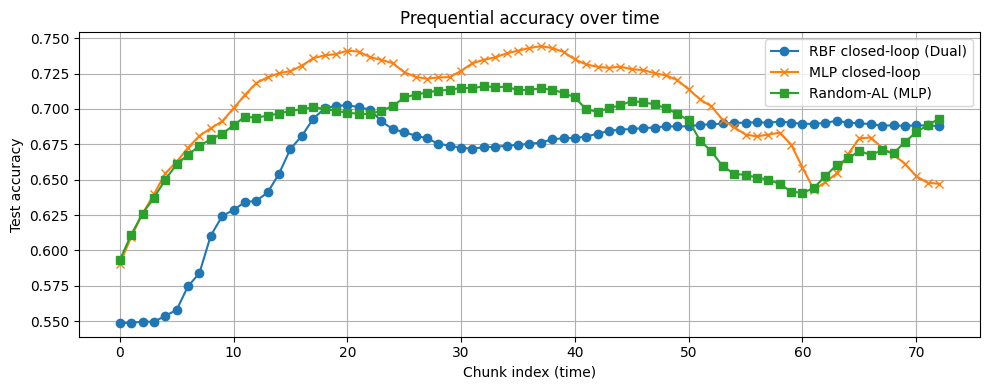

Saved results/accuracy_vs_labeled_all_dual.png


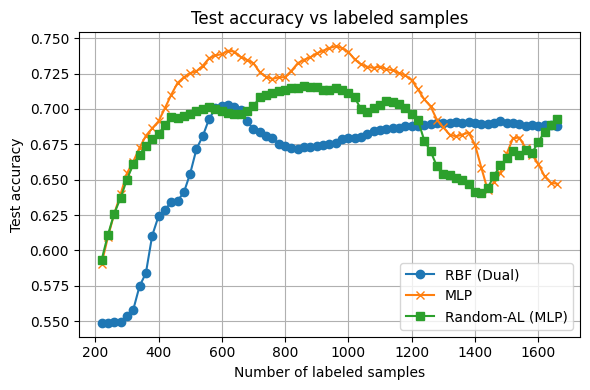

In [8]:
logs_pkg = joblib.load('results/all_logs_and_runs_dual.joblib')
logs_rbf = logs_pkg['rbf']
logs_mlp = logs_pkg['mlp']
logs_rand = logs_pkg['rand']
plt.figure(figsize=(10,4))
plt.plot(logs_rbf['chunk'], logs_rbf['acc_test'], marker='o', label='RBF closed-loop (Dual)')
plt.plot(logs_mlp['chunk'], logs_mlp['acc_test'], marker='x', label='MLP closed-loop')
plt.plot(logs_rand['chunk'], logs_rand['acc_test'], marker='s', label='Random-AL (MLP)')
plt.xlabel('Chunk index (time)')
plt.ylabel('Test accuracy')
plt.title('Prequential accuracy over time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('results/prequential_accuracy_all_dual.png', dpi=180)
print('Saved results/prequential_accuracy_all_dual.png')
plt.show()
plt.figure(figsize=(6,4))
plt.plot(logs_rbf['n_labeled'], logs_rbf['acc_test'], marker='o', label='RBF (Dual)')
plt.plot(logs_mlp['n_labeled'], logs_mlp['acc_test'], marker='x', label='MLP')
plt.plot(logs_rand['n_labeled'], logs_rand['acc_test'], marker='s', label='Random-AL (MLP)')
plt.xlabel('Number of labeled samples')
plt.ylabel('Test accuracy')
plt.title('Test accuracy vs labeled samples')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('results/accuracy_vs_labeled_all_dual.png', dpi=180)
print('Saved results/accuracy_vs_labeled_all_dual.png')
plt.show()


Saved results/rbf_centers_pca_dual.png


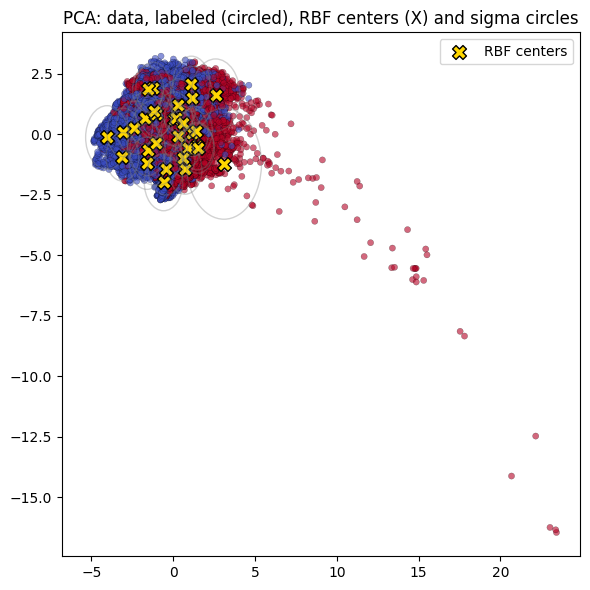

In [9]:
def plot_rbf_centers_pca(rbf_model, X_all_scaled, y_all, labeled_idx=None, pca=None, ax=None, alpha=0.35):
    if pca is None:
        pca = PCA(n_components=2, random_state=0)
        Z = pca.fit_transform(X_all_scaled)
    else:
        Z = pca.transform(X_all_scaled)
    centers = rbf_model.centers
    centers_p = pca.transform(centers)
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(Z[:,0], Z[:,1], c=y_all, cmap='coolwarm', s=20, alpha=0.6, edgecolors='k', linewidths=0.2)
    if labeled_idx is not None and len(labeled_idx)>0:
        zl = Z[labeled_idx]
        ax.scatter(zl[:,0], zl[:,1], facecolors='none', edgecolors='k', s=70, linewidths=1.2, label='labeled')
    ax.scatter(centers_p[:,0], centers_p[:,1], marker='X', s=100, c='gold', edgecolors='k', label='RBF centers')
    try:
        eps = 1e-4
        u = np.zeros(centers.shape[1])
        u[0] = 1.0
        u_p = pca.transform(centers + eps*u) - pca.transform(centers)
        scale = np.mean(np.linalg.norm(u_p, axis=1) / eps)
    except Exception:
        scale = 1.0
    for (cx, cy), sigma in zip(centers_p, rbf_model.sigmas):
        rad = float(sigma * scale)
        ell = Ellipse((cx, cy), width=2*rad, height=2*rad, edgecolor='gray', facecolor='none', alpha=alpha)
        ax.add_patch(ell)
    ax.set_title('PCA: data, labeled (circled), RBF centers (X) and sigma circles')
    ax.legend()
    return pca, ax

res_pkg = joblib.load('results/all_logs_and_runs_dual.joblib') if os.path.exists('results/all_logs_and_runs_dual.joblib') else None
if res_pkg is None:
    print('Run Cell 7 first to generate results')
else:
    res_rbf = res_pkg['res_rbf']
    X_scaled_full = res_rbf['X_rest_scaled']
    y_rest = res_rbf.get('y_rest', y[:len(X_scaled_full)])  # Use y_rest if available, otherwise slice y
    pca_obj, ax = plot_rbf_centers_pca(res_rbf['model'], X_scaled_full, y_rest, labeled_idx=None)
    plt.tight_layout()
    plt.savefig('results/rbf_centers_pca_dual.png', dpi=180)
    print('Saved results/rbf_centers_pca_dual.png')
    plt.show()


Saved results/centers_snapshots_grid_dual.png


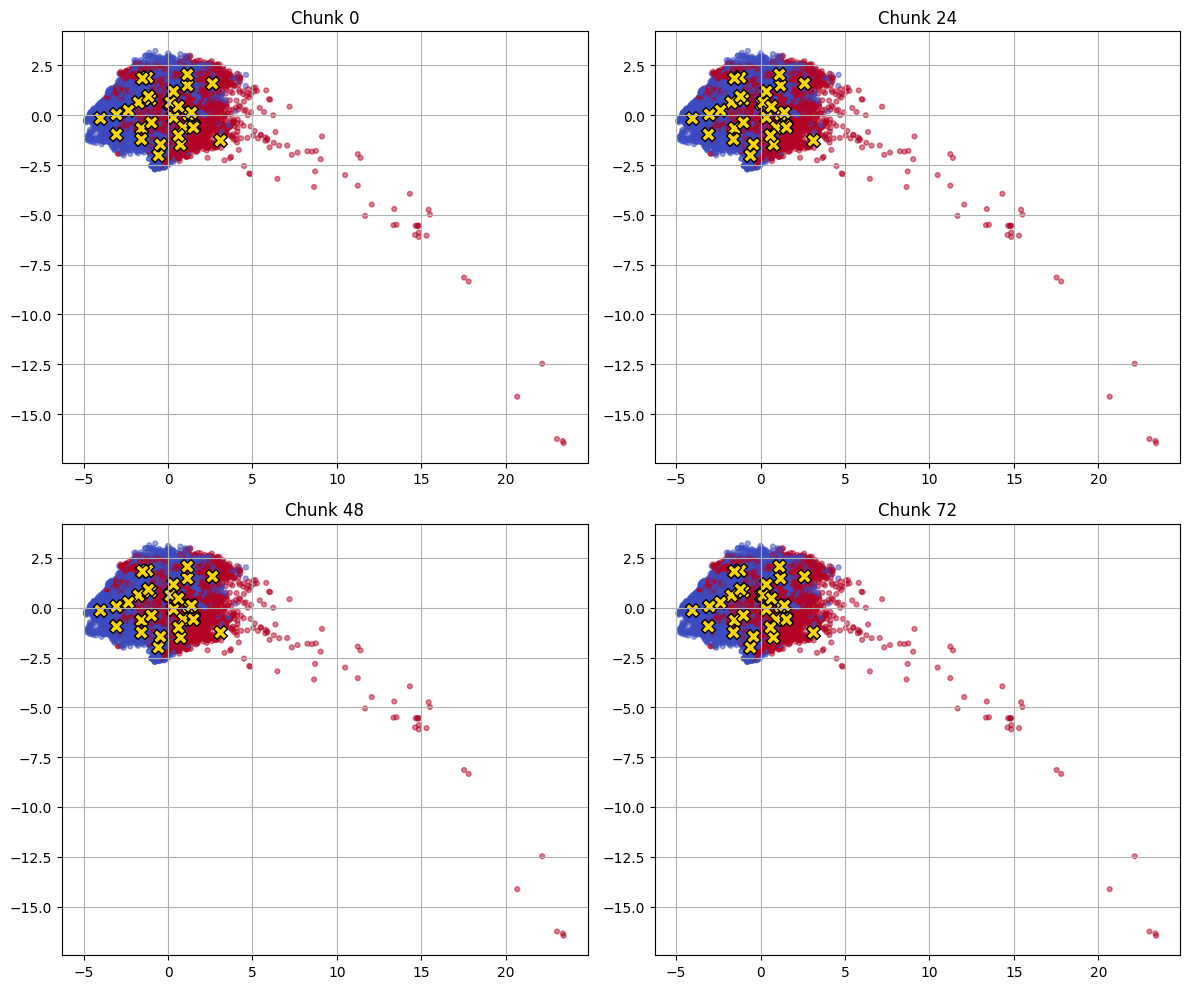

In [10]:
def plot_centers_snapshots(centers_history, X_scaled, y_all, snapshot_chunks=None, pca=None):
    if snapshot_chunks is None:
        keys = sorted(list(centers_history.keys()))
        L = len(keys)
        idxs = [keys[0], keys[L//3], keys[(2*L)//3], keys[-1]] if L>3 else keys
    else:
        idxs = snapshot_chunks
    if pca is None:
        pca = PCA(n_components=2, random_state=0).fit(X_scaled)
    fig, axes = plt.subplots(2,2, figsize=(12,10))
    axes = axes.flatten()
    for ax, ch in zip(axes, idxs):
        centers_t, labeled_idx_t = centers_history[ch]
        Z_full = pca.transform(X_scaled)
        centers_p = pca.transform(centers_t)
        ax.scatter(Z_full[:,0], Z_full[:,1], c=y_all, cmap='coolwarm', s=12, alpha=0.5)
        ax.scatter(centers_p[:,0], centers_p[:,1], marker='X', s=100, c='gold', edgecolors='k')
        ax.set_title(f'Chunk {ch}')
        ax.grid(True)
    plt.tight_layout()
    plt.savefig('results/centers_snapshots_grid_dual.png', dpi=180)
    print('Saved results/centers_snapshots_grid_dual.png')
    plt.show()

res_pkg = joblib.load('results/all_logs_and_runs_dual.joblib') if os.path.exists('results/all_logs_and_runs_dual.joblib') else None
if res_pkg is None:
    print('Run Cell 7 first to generate results')
else:
    res_rbf = res_pkg['res_rbf']
    centers_hist = res_rbf['centers_history']
    X_scaled_full = res_rbf['X_rest_scaled']
    y_rest = res_rbf.get('y_rest', y[:len(X_scaled_full)])  # Use y_rest if available, otherwise slice y
    plot_centers_snapshots(centers_hist, X_scaled_full, y_rest)
